# Build a model to predict Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc. In contrast to the previous assignment, this time the goal is outperform the state-of-the-art OPERA Koc model:

 - Paper on OPERA models, including the one for Koc: https://doi.org/10.1186/s13321-018-0263-1
 - Performance of the OPERA Koc model on the test set: R2 = 0.71, RMSE = 0.61
 - Model: weighted k-Nearest Neighbors regressor trained on 12 selected PaDEL descriptors (similar to RDKit descriptors)

As you are now a modelling expert, it is open to you which model architecture you use. BUT we ask you to justify your choices! 


#### Tasks:

1) Load the training data and split it into train and test according to the 'Tr_1_Tst_0' column

2) Think about a suitable architecture:
    - Suitable descriptors/fingerprints
    - Model choice (fine-tune a pretrained neural network? GNN? Ensemble method? Gaussian Process? ...?)
    - Consider providing an AD for your model (using an AD metric, or by defining the content of the training data (e.g., organic chemicals with a MW between x and y)
    - Consider providing prediction uncertainty: If you decide to do so, provide uncertainty calibration. If not, explain why.
    
        
3) Train the model on the same training data used in the paper (Tr_1_Tst_0 == 1). 

4) Consider tuning hyperparameters (e.g., using GridSearchCV and on a short list of parameters) 

5) Evaluate model on the test set (Tr_1_Tst_0 == 0), ONLY ONCE ! 

6) Compare your model performance on the test set to the OPERA model. 

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD


In [53]:
# import
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
import seaborn as sns
from matplotlib import pyplot as plt


#### 1. Load training data

In [43]:
# Loading the data from the .sdf file
supplier = Chem.SDMolSupplier("KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    }
    for m in supplier if m is not None
])

In [44]:
# The data is pre-split in training and testing:
df.groupby('Tr_1_Tst_0').count()

,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,
0,184,184,184
1,544,544,544


In [45]:
df.shape

(728, 4)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SMILES          728 non-null    object
 1   preferred_name  728 non-null    object
 2   LogKOC          728 non-null    object
 3   Tr_1_Tst_0      728 non-null    object
dtypes: object(4)
memory usage: 22.9+ KB


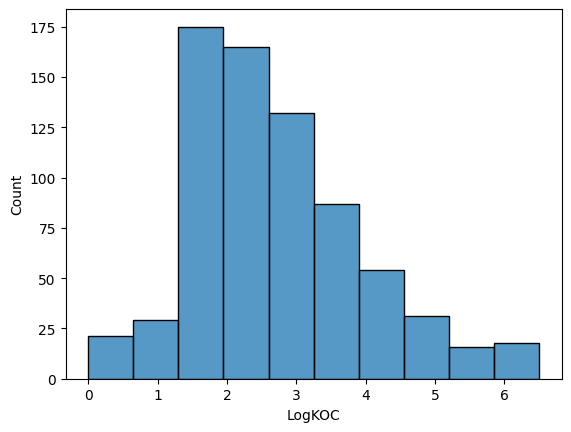

In [ ]:
df_hist = df.copy()
df_hist["LogKOC"] = pd.to_numeric(df_hist["LogKOC"], errors="coerce")


sns.histplot(df_hist["LogKOC"], bins=10)
plt.show()

#can use adaboost, not visible outliers :D

In [47]:
df.groupby('Tr_1_Tst_0').count()

,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,
0,184,184,184
1,544,544,544


In [48]:
train_df = df[df["Tr_1_Tst_0"] == "1"]
test_df = df[df["Tr_1_Tst_0"] == "0"]

In [49]:
print(train_df.shape)
print(test_df.shape)

(544, 4)
(184, 4)


#### 2. Build a supervised model of your choice

In [50]:
def smiles_to_fp(smiles, radius=3, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    ConvertToNumpyArray(fp, arr)

    return arr

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    descriptors = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRadicalElectrons(mol),
        Descriptors.NumValenceElectrons(mol)]

    return np.array(descriptors)



In [51]:
def features_from_mol(smiles):
    fp = smiles_to_fp(smiles)
    desc = calc_descriptors(smiles)
    features = np.concatenate([fp, desc])
    return features

In [52]:
X_train = np.array([features_from_mol(s) for s in train_df["SMILES"]])
X_test = np.array([features_from_mol(s) for s in test_df["SMILES"]])
y_train = train_df["LogKOC"].values
y_test = test_df["LogKOC"].values

[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerator
[16:16:01] DEPRECATION WARNING: please use MorganGenerat

In [65]:
# Model

from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = AdaBoostRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


#### 3. Model performance on test set
--> **TEST ONLY ONCE !**

In [64]:
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

RMSE: 0.549
MAE: 0.442
R²: 0.769


In [66]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

# Train AdaBoost
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train)

distances, neighbor_indices = nn.kneighbors(X_test)

ad_distance = distances.mean(axis=1)

train_distances, _ = nn.kneighbors(X_train)
train_ad_distance = train_distances[:, 1:].mean(axis=1)  # skip itself as nearest neighbor

threshold = np.percentile(train_ad_distance, 95)

inside_ad = ad_distance <= threshold

results = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "AD_distance": ad_distance,
    "inside_AD": inside_ad
})

results.head()

,y_true,y_pred,AD_distance,inside_AD
0,1.4,1.567158,6.281648,True
1,2.01,2.310223,7.809170,True
2,1.85,2.421974,11.322228,True
3,5.3,4.910606,7.374990,True
4,5.37,5.085000,10.250073,True


<Axes: xlabel='AD_distance', ylabel='Count'>

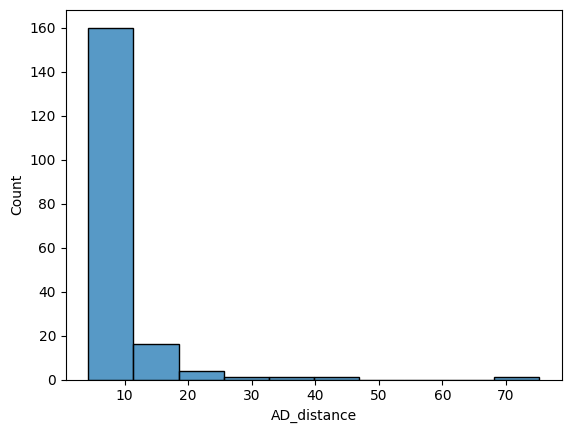

In [71]:
sns.histplot(results["AD_distance"], bins=10)

AD good, not many points with large AD distance

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD

### Answers: 

1. I used an ADABoost Regressor because it works with non-linearity, is often better than a single tree (no normalisation and scaling needed) and works well on relatively simple datasets like our descriptors which is very structured and has defined features.
2. The model outperformed the OPERA model which had a R2 of 0.71 and a RMSE of 0.61 => My model: R^2 of 0.769 and a RMSE of 0.549
3. I did not predict uncertainty because the standard AdaBoost Regressor does not directly provide calibrated uncertainty estimates. While AdaBoost is an ensemble model, it sequentially trains weak learners to improve predictions rather than independently estimating prediction variance like Random Forests from which the uncertainty can be calculated.
4. I provided an AD to see how if the model is able to reliably extrapolate values that might be outside the training chemical feature space. The AD was defined using a nearest-neighbour approach. For each compound, its distance to the next 5 nearest neighbours was calculated and it was defined that the distance to those 5 neighbours had to be similar to 95% of the other mean distances.
